<a href="https://colab.research.google.com/github/sanjaypras/cfdb_pred/blob/main/cfdb_practice_pt2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import keras

In [ ]:
df = pd.read_csv('cfb_recruits_2015_2021.csv')

In [ ]:
df[:20]

,year,name,position,height,weight,stars,rating,ranking,school,committed_to,city,state,country,lat,lng,power_5
0,2015,Trenton Thompson,DT,74.5,313.0,5,0.9991,1,Westover,Georgia,Albany,GA,USA,31.578206,-84.155681,1
1,2015,Martez Ivey,OT,77.5,275.0,5,0.9991,2,Apopka,Florida,Apopka,FL,USA,28.677968,-81.511521,1
2,2015,Byron Cowart,SDE,76.0,250.0,5,0.9987,3,Armwood,Auburn,Seffner,FL,USA,27.998541,-82.274884,1
3,2015,Iman Marshall,CB,73.0,190.0,5,0.9985,4,Long Beach Poly,USC,Long Beach,CA,USA,33.769016,-118.191605,1
4,2015,Derwin James,S,74.0,201.0,5,0.9982,5,Haines City,Florida State,Auburndale,FL,USA,28.107088,-81.803580,1
5,2015,Kahlil McKenzie,DT,75.0,339.0,5,0.9972,6,Clayton Valley,Tennessee,Concord,CA,USA,37.976852,-122.033562,1
6,2015,CeCe Jefferson,SDE,74.0,275.0,5,0.9952,7,Baker County,Florida,Glen St. Mary,FL,USA,30.275791,-82.160669,1
7,2015,Josh Sweat,WDE,77.0,240.0,5,0.9949,8,Oscar Smith,Florida State,Chesapeake,VA,USA,36.718371,-76.246680,1
8,2015,Kevin Toliver II,CB,74.0,185.0,5,0.9949,9,Trinity Christian Academy,LSU,Jacksonville,FL,USA,30.332184,-81.655651,1
9,2015,Malik Jefferson,OLB,74.5,215.0,5,0.9934,10,Poteet,Texas,Mesquite,TX,USA,32.766610,-96.599472,1


In [ ]:
df.head()

,year,name,position,height,weight,stars,rating,ranking,school,committed_to,city,state,country,lat,lng
0,2015,Trenton Thompson,DT,74.5,313.0,5,0.9991,1,Westover,Georgia,Albany,GA,USA,31.578206,-84.155681
1,2015,Martez Ivey,OT,77.5,275.0,5,0.9991,2,Apopka,Florida,Apopka,FL,USA,28.677968,-81.511521
2,2015,Byron Cowart,SDE,76.0,250.0,5,0.9987,3,Armwood,Auburn,Seffner,FL,USA,27.998541,-82.274884
3,2015,Iman Marshall,CB,73.0,190.0,5,0.9985,4,Long Beach Poly,USC,Long Beach,CA,USA,33.769016,-118.191605
4,2015,Derwin James,S,74.0,201.0,5,0.9982,5,Haines City,Florida State,Auburndale,FL,USA,28.107088,-81.803580


In [ ]:
df.describe()

,year,height,weight,stars,rating,ranking,lat,lng
count,25942.000000,25942.000000,25942.000000,25942.000000,25942.000000,25942.000000,25843.000000,25843.000000
mean,2017.886863,73.702164,217.139658,2.752178,0.822605,1903.109591,35.142908,-92.757818
std,1.906137,2.684209,43.995530,0.652240,0.054250,1116.378097,5.363464,15.289583
min,2015.000000,0.000000,27.000000,2.000000,0.699600,1.000000,-14.275479,-170.704830
25%,2016.000000,72.000000,182.000000,2.000000,0.780000,937.000000,31.775415,-97.105624
50%,2018.000000,74.000000,205.000000,3.000000,0.817500,1906.000000,34.097510,-87.503152
75%,2020.000000,76.000000,245.000000,3.000000,0.854400,2835.000000,39.273786,-81.949804
max,2021.000000,83.000000,425.000000,5.000000,1.000000,4265.000000,65.188685,-70.254860


we are going to be seeing if how to predict whetehr or not the player went to a power 4/5 conference or not. we first need to make a new feature, power_5, which will be a boolean telling us which of these players went to a power 5 or not college

In [ ]:
p5_schools = [
    # ACC
    'Boston College', 'Clemson', 'Duke', 'Florida State', 'Georgia Tech',
    'Louisville', 'Miami', 'North Carolina', 'NC State', 'Pittsburgh',
    'Syracuse', 'Virginia', 'Virginia Tech', 'Wake Forest', 'Notre Dame',
    # Big Ten
    'Illinois', 'Indiana', 'Iowa', 'Maryland', 'Michigan', 'Michigan State',
    'Minnesota', 'Nebraska', 'Northwestern', 'Ohio State', 'Penn State',
    'Purdue', 'Rutgers', 'Wisconsin',
    # Big 12
    'Baylor', 'Iowa State', 'Kansas', 'Kansas State', 'Oklahoma',
    'Oklahoma State', 'TCU', 'Texas', 'Texas Tech', 'West Virginia',
    # Pac-12
    'Arizona', 'Arizona State', 'California', 'Colorado', 'Oregon',
    'Oregon State', 'Stanford', 'UCLA', 'USC', 'Utah', 'Washington', 'Washington State',
    # SEC
    'Alabama', 'Arkansas', 'Auburn', 'Florida', 'Georgia', 'Kentucky',
    'LSU', 'Mississippi State', 'Missouri', 'Ole Miss', 'South Carolina',
    'Tennessee', 'Texas A&M', 'Vanderbilt'
]

In [ ]:
# Create the column
# We use .strip() in case there are accidental spaces in your school names
df['power_5'] = df['committed_to'].str.strip().isin(p5_schools).astype(int)

# Quick check to see the distribution
print(df['power_5'].value_counts())

# See a sample of the mapping
print(df[['committed_to', 'power_5']].sample(10))

power_5
0    19410
1     6532
Name: count, dtype: int64
      committed_to  power_5
9473       Indiana        1
2269           NaN        0
25140     Illinois        1
20507          NaN        0
24777   Miami (OH)        0
3099     UL Monroe        0
2933           NaN        0
20498          NaN        0
23032          NaN        0
19407    Air Force        0


In [ ]:
# To see which schools were NOT caught by your P5 list
# (Good for catching spelling errors like 'Fla. State' vs 'Florida State')
non_p5 = df[df['power_5'] == 0]['committed_to'].unique()
print(non_p5)

['San Diego State' 'Boise State' 'UCF' 'Fresno State' nan 'Miami (OH)'
 'San José State' 'Tulsa' 'BYU' 'Houston' 'Bowling Green' 'Temple'
 'Western Michigan' 'Louisiana' 'Marshall' 'Louisiana Tech' 'Toledo' 'SMU'
 'Kent State' 'South Florida' 'Rice' 'Massachusetts' 'Old Dominion'
 'Ball State' 'Middle Tennessee' 'Florida Atlantic' 'North Texas'
 "Hawai'i" 'Ohio' 'Cincinnati' 'Tulane' 'William & Mary' 'Marist'
 'Alcorn State' 'App State' 'Northern Arizona' 'UNLV' 'Yale'
 'Florida International' 'Georgia Southern' 'South Alabama' 'Liberty'
 'James Madison' 'Memphis' 'Towson' 'Monmouth' 'Nevada' 'East Carolina'
 'Air Force' 'Northern Colorado' 'UC Davis' 'Incarnate Word' 'Texas State'
 'Western Kentucky' 'Arkansas State' 'Eastern Michigan'
 'Northern Illinois' 'New Mexico' 'Jacksonville State' 'Western Illinois'
 'Hampton' 'Florida A&M' 'Cal Poly' 'Richmond' 'Western Carolina'
 'Charlotte' 'Samford' 'Colorado State' 'Central Michigan' 'Montana'
 'Buffalo' 'Bucknell' 'Robert Morris' 'UTSA'

good, doesnt look like there are any typos

In [ ]:
df.head()

,year,name,position,height,weight,stars,rating,ranking,school,committed_to,city,state,country,lat,lng,power_5
0,2015,Trenton Thompson,DT,74.5,313.0,5,0.9991,1,Westover,Georgia,Albany,GA,USA,31.578206,-84.155681,1
1,2015,Martez Ivey,OT,77.5,275.0,5,0.9991,2,Apopka,Florida,Apopka,FL,USA,28.677968,-81.511521,1
2,2015,Byron Cowart,SDE,76.0,250.0,5,0.9987,3,Armwood,Auburn,Seffner,FL,USA,27.998541,-82.274884,1
3,2015,Iman Marshall,CB,73.0,190.0,5,0.9985,4,Long Beach Poly,USC,Long Beach,CA,USA,33.769016,-118.191605,1
4,2015,Derwin James,S,74.0,201.0,5,0.9982,5,Haines City,Florida State,Auburndale,FL,USA,28.107088,-81.803580,1


<Axes: xlabel='height', ylabel='weight'>

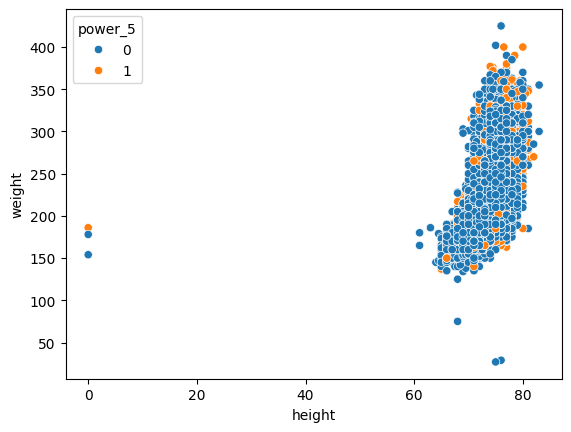

In [ ]:
sns.scatterplot(data=df, x='height', y='weight', hue='power_5')

looks like we have some outliers

In [ ]:
df = df[df['height'] != 0]# Drops all rows where height is equal to 0
df = df[df['weight'] >= 100]# Drops all rows where weight is less than 100

<Axes: xlabel='height', ylabel='weight'>

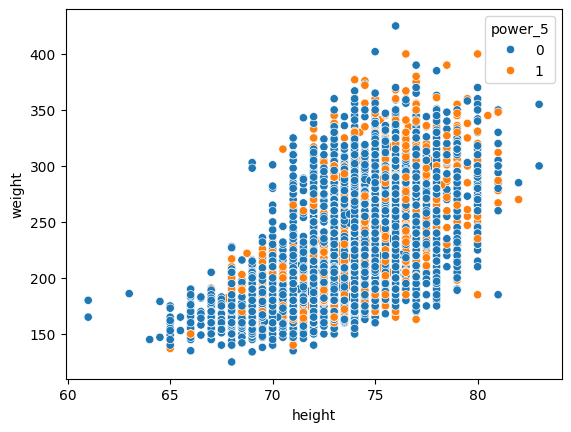

In [ ]:
sns.scatterplot(data=df, x='height', y='weight', hue='power_5')

we can try plotting it against rating

<Axes: xlabel='rating', ylabel='height'>

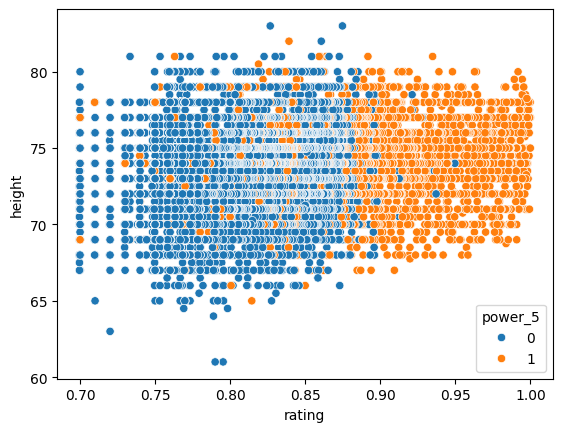

In [ ]:
sns.scatterplot(data=df, x='rating', y='height', hue='power_5')

In [ ]:
df.describe()

,year,height,weight,stars,rating,ranking,lat,lng,power_5
count,25936.000000,25936.000000,25936.000000,25936.000000,25936.000000,25936.000000,25837.000000,25837.000000,25936.000000
mean,2017.887184,73.710770,217.164867,2.752313,0.822614,1902.913749,35.143635,-92.758682,0.251812
std,1.906205,2.564509,43.957546,0.652230,0.054252,1116.398244,5.363316,15.289863,0.434062
min,2015.000000,61.000000,125.000000,2.000000,0.699600,1.000000,-14.275479,-170.704830,0.000000
25%,2016.000000,72.000000,182.000000,2.000000,0.780000,936.000000,31.775415,-97.105624,0.000000
50%,2018.000000,74.000000,205.000000,3.000000,0.817500,1906.000000,34.097510,-87.529584,0.000000
75%,2020.000000,76.000000,245.000000,3.000000,0.854450,2835.000000,39.277616,-81.949804,1.000000
max,2021.000000,83.000000,425.000000,5.000000,1.000000,4265.000000,65.188685,-70.254860,1.000000


In [ ]:
#df_no_nums = df.drop(columns = ['name', 'year', 'position', 'school', 'committed_to', 'city', 'state', 'country'])

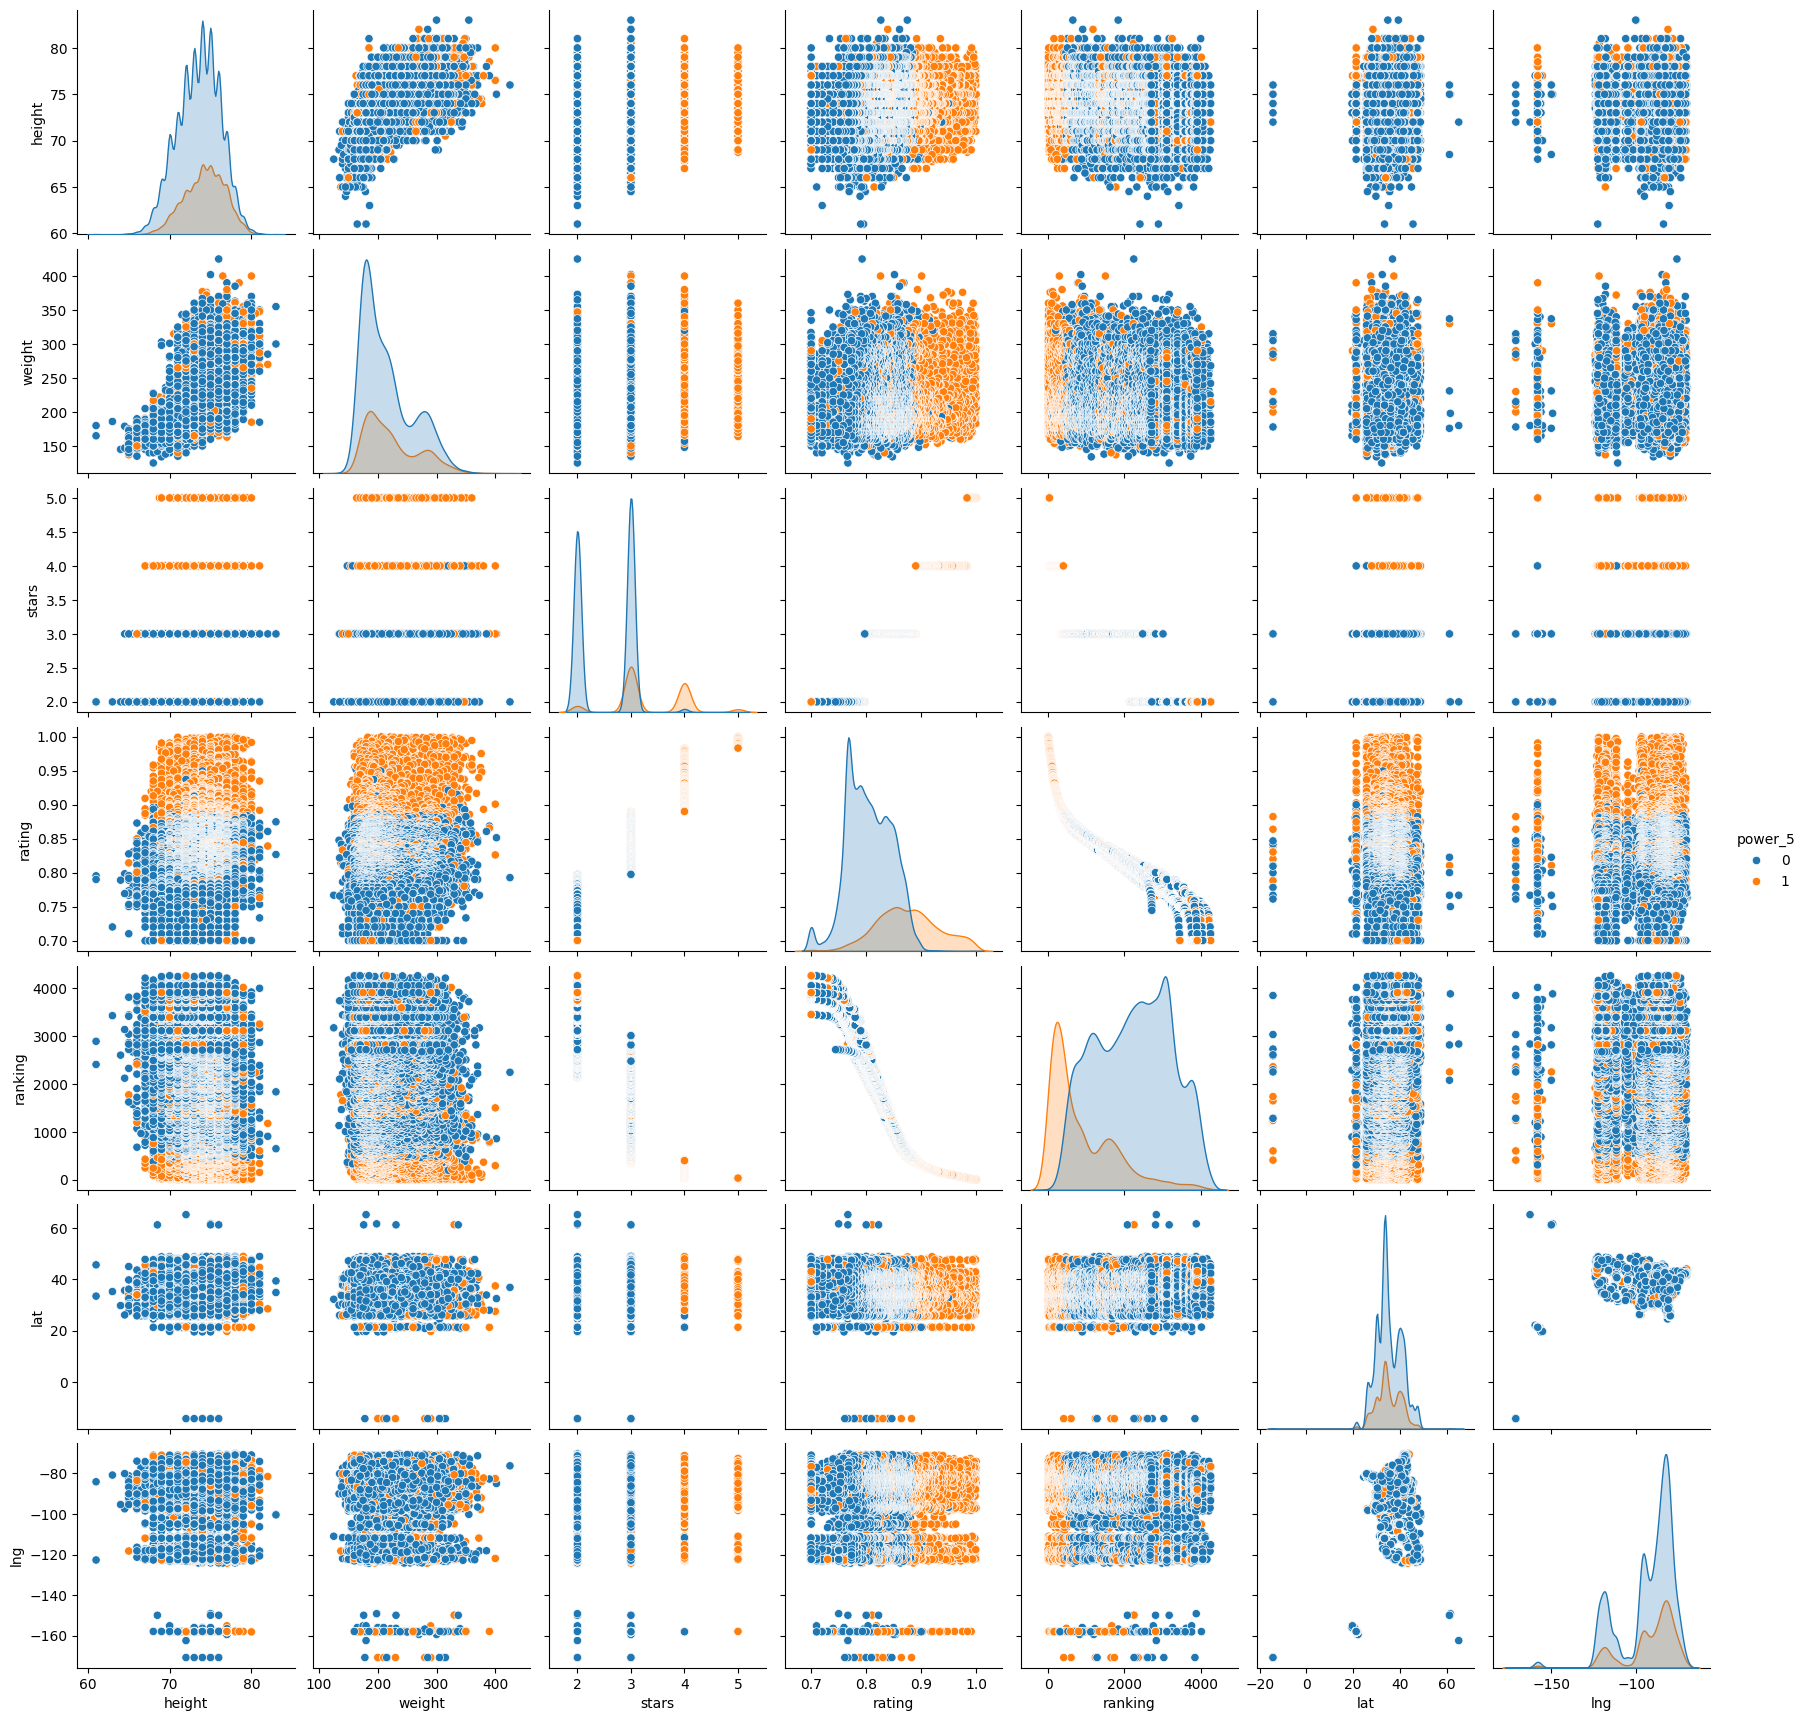

In [ ]:
sns.pairplot(data=df_no_nums, hue='power_5')

<Axes: >

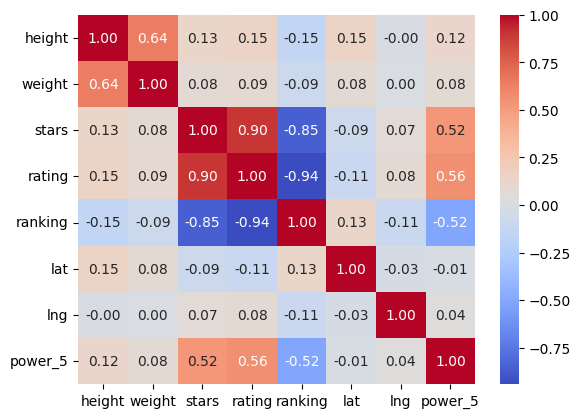

In [ ]:

sns.heatmap(df_no_nums.corr(), annot=True, fmt=".2f", cmap="coolwarm")

lets try a neural network

In [ ]:
import pandas as pd

# List the columns that are text-based (categorical)
categorical_cols = ['position', 'state']

# Create dummy variables
# drop_first=True prevents "multicollinearity" (perfectly predicting one column from others)
df_final = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Now define your X and y again
X = df_final.drop(['power_5', 'name', 'committed_to', 'school', 'city', 'country', 'lat', 'lng', 'year'], axis=1) # Drop non-numeric/target columns
y = df_final['power_5']

print(f"New feature count: {X.shape[1]} (up from your original count)")
print(X.columns.tolist())

New feature count: 90 (up from your original count)
['height', 'weight', 'stars', 'rating', 'ranking', 'position_ATH', 'position_CB', 'position_DL', 'position_DT', 'position_DUAL', 'position_EDGE', 'position_FB', 'position_ILB', 'position_IOL', 'position_K', 'position_LB', 'position_LS', 'position_OC', 'position_OG', 'position_OLB', 'position_OT', 'position_P', 'position_PRO', 'position_QB', 'position_RB', 'position_RET', 'position_S', 'position_SDE', 'position_TE', 'position_WDE', 'position_WR', 'state_AL', 'state_AR', 'state_AS', 'state_AUST', 'state_AZ', 'state_BELG', 'state_CA', 'state_CANA', 'state_CO', 'state_CT', 'state_DC', 'state_DE', 'state_DENM', 'state_ENGL', 'state_FL', 'state_FRAN', 'state_GA', 'state_GERM', 'state_HI', 'state_IA', 'state_ID', 'state_IL', 'state_IN', 'state_KS', 'state_KY', 'state_LA', 'state_MA', 'state_MD', 'state_ME', 'state_MI', 'state_MN', 'state_MO', 'state_MS', 'state_MT', 'state_NC', 'state_ND', 'state_NE', 'state_NETH', 'state_NH', 'state_NJ', 's

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Scale data (Mandatory for Neural Networks)
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Build the Model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2), # Prevents overfitting by randomly turning off 20% of neurons
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# 3. Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
)

# 4. Train
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2, # Watch performance on a small slice of data
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8112 - loss: 0.4385 - precision: 0.6938 - recall: 0.4393 - val_accuracy: 0.8390 - val_loss: 0.3813 - val_precision: 0.7898 - val_recall: 0.5080
Epoch 2/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8415 - loss: 0.3795 - precision: 0.7769 - recall: 0.5142 - val_accuracy: 0.8417 - val_loss: 0.3760 - val_precision: 0.8082 - val_recall: 0.5023
Epoch 3/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8435 - loss: 0.3704 - precision: 0.7850 - recall: 0.5154 - val_accuracy: 0.8400 - val_loss: 0.3742 - val_precision: 0.7988 - val_recall: 0.5033
Epoch 4/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8447 - loss: 0.3658 - precision: 0.7983 - recall: 0.5072 - val_accuracy: 0.8383 - val_loss: 0.3742 - val_precision: 0.7847 - val_recall: 0.5099
Epoch 5/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8464 - loss: 0.3623 - precision: 0.8011 - recall: 0.5132 - val_accuracy: 0.8390 - val_loss: 0.

,rating,power_5
0,0.9991,1
1,0.9991,1
2,0.9987,1
3,0.9985,1
4,0.9982,1


In [ ]:
# Calculate weights based on your 3:1 ratio
# This forces the NN to care 3x more about catching P5 players
weights = {0: 1.0, 1: 3.0}

history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=weights,  # <--- The Magic Ingredient
    verbose=1
)

Epoch 1/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8146 - loss: 0.6394 - precision: 0.6058 - recall: 0.7408 - val_accuracy: 0.7920 - val_loss: 0.4504 - val_precision: 0.5773 - val_recall: 0.7080
Epoch 2/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8100 - loss: 0.6294 - precision: 0.5943 - recall: 0.7572 - val_accuracy: 0.7858 - val_loss: 0.4579 - val_precision: 0.5637 - val_recall: 0.7315
Epoch 3/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8112 - loss: 0.6273 - precision: 0.5954 - recall: 0.7659 - val_accuracy: 0.7928 - val_loss: 0.4461 - val_precision: 0.5783 - val_recall: 0.7108
Epoch 4/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8101 - loss: 0.6262 - precision: 0.5929 - recall: 0.7685 - val_accuracy: 0.7836 - val_loss: 0.4590 - val_precision: 0.5602 - val_recall: 0.7296
Epoch 5/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8099 - loss: 0.6240 - precision: 0.5925 - recall: 0.7683 - val_accuracy: 0.7875 - val_loss: 0.

right now, its not working that well(xgb is better), so lets try a bigger model

,rating
0,0.9991
1,0.9991
2,0.9987
3,0.9985
4,0.9982


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers

# 1. Build a much more complex model
model_deep = Sequential([
    # Layer 1: 128 units
    Dense(128, activation='relu',
          kernel_regularizer=regularizers.l2(0.01), # Applied here
          input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(), # Stabilizes learning
    Dropout(0.4),         # Heavier dropout to prevent overfitting

    # Layer 2: 64 units
    Dense(64, activation='relu',
          kernel_regularizer=regularizers.l2(0.01)),
    BatchNormalization(),
    Dropout(0.4),

    # Layer 3: 32 units
    Dense(32, activation='relu'),

    # Output Layer
    Dense(1, activation='sigmoid')
])

# 2. Compile with a slightly slower learning rate for stability
model_deep.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
)

# 3. Train with the 3:1 class weight
weights = {0: 1.0, 1: 3.0}

history_deep = model_deep.fit(
    X_train_scaled, y_train,
    epochs=50, # More epochs for a deeper model
    batch_size=64,
    validation_split=0.2,
    class_weight=weights,
    verbose=1
)

Epoch 1/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6862 - loss: 2.0900 - precision_4: 0.4226 - recall_4: 0.6951 - val_accuracy: 0.8096 - val_loss: 1.2776 - val_precision_4: 0.6253 - val_recall_4: 0.6441
Epoch 2/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7676 - loss: 1.3878 - precision_4: 0.5259 - recall_4: 0.7199 - val_accuracy: 0.7971 - val_loss: 0.9299 - val_precision_4: 0.5866 - val_recall_4: 0.7089
Epoch 3/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7764 - loss: 1.1050 - precision_4: 0.5394 - recall_4: 0.7262 - val_accuracy: 0.8029 - val_loss: 0.7336 - val_precision_4: 0.5976 - val_recall_4: 0.7099
Epoch 4/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7792 - loss: 0.9501 - precision_4: 0.5434 - recall_4: 0.7341 - val_accuracy: 0.7920 - val_loss: 0.6325 - val_precision_4: 0.5783 - val_recall_4: 0.7005
Epoch 5/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7797 - loss: 0.8656 - precision_4: 0.5438 - recall_4: 0.7399

After testing various architectures, the XGBoost (Weighted) model emerges as the superior "Talent Hunter," boasting an elite 78% recall that captures significantly more Power 5 sleepers than its competitors. While the Decision Tree offers higher precision (87%) for those who prioritize a "safe bet" with fewer false positives, it remains too conservative for comprehensive scouting. The Neural Network ultimately failed to justify its complexity, stalling at 67% recall and proving that larger models don't always yield better insights in the noisy world of recruiting data.

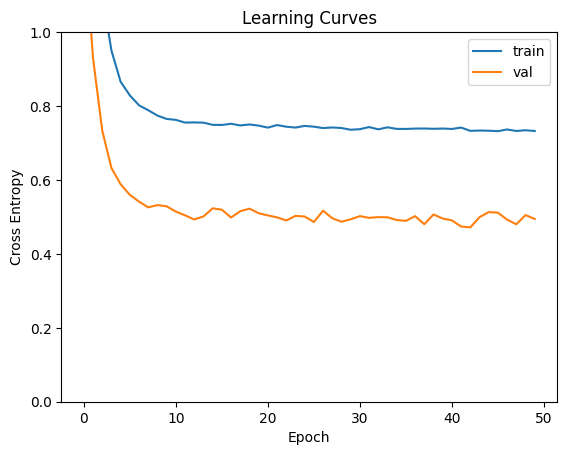

"pyplot.title('Learning Curves')\npyplot.xlabel('Epoch')\npyplot.ylabel('Cross Entropy')\npyplot.plot(history.history['loss'], label='train')\npyplot.plot(history.history['val_loss'], label='val')\nplt.ylim(0, 1)\npyplot.legend()\npyplot.show()"

In [ ]:
from matplotlib import pyplot

pyplot.title('Learning Curves')
pyplot.xlabel('Epoch')
pyplot.ylabel('Cross Entropy')
pyplot.plot(history_deep.history['loss'], label='train')
pyplot.plot(history_deep.history['val_loss'], label='val')
plt.ylim(0, 1)
pyplot.legend()
pyplot.show()

"""pyplot.title('Learning Curves')
pyplot.xlabel('Epoch')
pyplot.ylabel('Cross Entropy')
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='val')
plt.ylim(0, 1)
pyplot.legend()
pyplot.show()"""

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

h_fix1 = model.fit(X_train_scaled, y_train,
          epochs=100,
          validation_split=0.2,
          class_weight=weights,
          callbacks=[early_stop]) # Automatically stops when orange line goes up

Epoch 1/100
519/519 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8156 - loss: 0.5944 - precision: 0.6001 - recall: 0.7883 - val_accuracy: 0.7848 - val_loss: 0.4889 - val_precision: 0.5624 - val_recall: 0.7277
Epoch 2/100
519/519 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8170 - loss: 0.5955 - precision: 0.6022 - recall: 0.7905 - val_accuracy: 0.7867 - val_loss: 0.4889 - val_precision: 0.5657 - val_recall: 0.7277
Epoch 3/100
519/519 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8162 - loss: 0.5983 - precision: 0.6006 - recall: 0.7917 - val_accuracy: 0.7904 - val_loss: 0.4850 - val_precision: 0.5723 - val_recall: 0.7249
Epoch 4/100
519/519 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8149 - loss: 0.6004 - precision: 0.5986 - recall: 0.7893 - val_accuracy: 0.7906 - val_loss: 0.4829 - val_precision: 0.5736 - val_recall: 0.7174
Epoch 5/100
519/519 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8129 - loss: 0.6014 - precision: 0.5948 - recall: 0.7902 - val_accuracy: 0.7880 - val_l

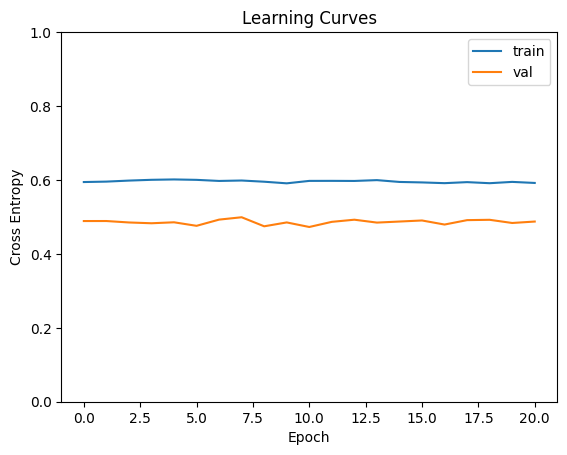

In [ ]:
pyplot.title('Learning Curves')
pyplot.xlabel('Epoch')
pyplot.ylabel('Cross Entropy')
pyplot.plot(h_fix1.history['loss'], label='train')
pyplot.plot(h_fix1.history['val_loss'], label='val')
plt.ylim(0, 1)
pyplot.legend()
pyplot.show()

cramer's v

In [ ]:
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(var1, var2):
    """ Calculate Cramer's V for two categorical variables. """
    # 1. Create the contingency table (cross-tab)
    confusion_matrix = pd.crosstab(var1, var2)

    # 2. Run the Chi-Square test
    chi2 = chi2_contingency(confusion_matrix)[0]

    # 3. Calculate N and the dimensions
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    # 4. Apply the formula
    # Note: Using (min(r, k) - 1) as the denominator
    return np.sqrt(phi2 / (min(r, k) - 1))

In [ ]:
# Example 1: How strongly is Position associated with Power 5?
val_pos = cramers_v(df['position'], df['power_5'])
print(f"Cramer's V (Position vs Power 5): {val_pos:.4f}")

# Example 2: How strongly are Stars associated with Power 5?
val_stars = cramers_v(df['stars'], df['power_5'])
print(f"Cramer's V (Stars vs Power 5): {val_stars:.4f}")

Cramer's V (Position vs Power 5): 0.0880
Cramer's V (Stars vs Power 5): 0.5779


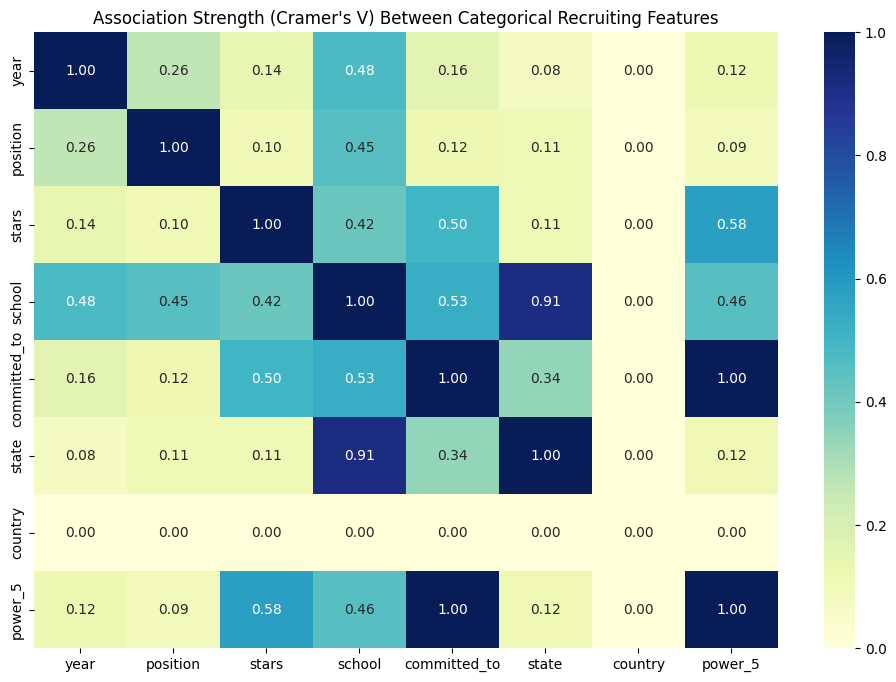

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

def cramers_v(var1, var2):
    # Drop rows where either variable is NaN for this specific calculation
    mask = ~(var1.isnull() | var2.isnull())
    if mask.sum() == 0: return 0

    confusion_matrix = pd.crosstab(var1[mask], var2[mask])
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    # Standard Cramer's V calculation
    return np.sqrt(phi2 / (min(r, k) - 1)) if min(r, k) > 1 else 0

# 1. Define strictly categorical features
cat_features = [
    'year', 'position', 'stars', 'school',
    'committed_to', 'state', 'country', 'power_5'
]

# 2. Filter list to only include columns that exist in your DataFrame
valid_cat_features = [f for f in cat_features if f in df.columns]

# 3. Compute Matrix
cat_cv_matrix = pd.DataFrame(index=valid_cat_features, columns=valid_cat_features)

for col1 in valid_cat_features:
    for col2 in valid_cat_features:
        cat_cv_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

# 4. Heatmap Visualization
plt.figure(figsize=(12, 8))
sns.heatmap(cat_cv_matrix.astype(float), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title("Association Strength (Cramer's V) Between Categorical Recruiting Features")
plt.show()

lets run basic logisitic regression

<Axes: xlabel='rating', ylabel='power_5'>

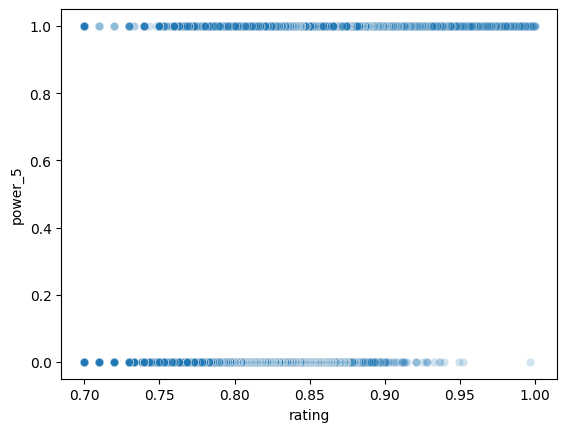

In [ ]:
sns.scatterplot(data=df, x='rating', y='power_5', alpha=0.2)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Data Cleaning
# Ensure no NaNs in the columns we're using
df_lr = df[['rating', 'power_5']].dropna()

X = df_lr[['rating']] # Predictor (Needs to be a 2D array/DataFrame)
y = df_lr['power_5']  # Target

# 2. Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Fit the Model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# 4. Evaluate
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

print("--- Model Performance ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

--- Model Performance ---
              precision    recall  f1-score   support

           0       0.85      0.97      0.91      3874
           1       0.87      0.47      0.61      1314

    accuracy                           0.85      5188
   macro avg       0.86      0.72      0.76      5188
weighted avg       0.85      0.85      0.83      5188

ROC-AUC Score: 0.8476


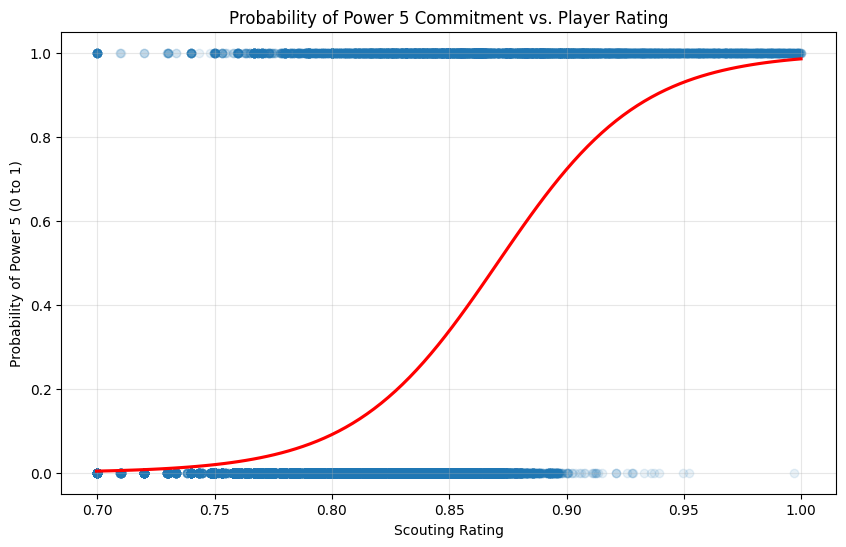

In [ ]:
plt.figure(figsize=(10, 6))

# Plot the actual data points (jittered slightly to see density)
sns.regplot(x='rating', y='power_5', data=df_lr, logistic=True,
            ci=None, scatter_kws={'alpha':0.1}, line_kws={'color':'red'})

plt.title('Probability of Power 5 Commitment vs. Player Rating')
plt.xlabel('Scouting Rating')
plt.ylabel('Probability of Power 5 (0 to 1)')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Calculate the Odds Ratio
odds_ratio = np.exp(log_reg.coef_[0][0] * 0.01)
print(f"Odds Ratio: {odds_ratio:.4f}")

Odds Ratio: 1.3035


In [ ]:
df.columns

Index(['year', 'name', 'position', 'height', 'weight', 'stars', 'rating',
       'ranking', 'school', 'committed_to', 'city', 'state', 'country', 'lat',
       'lng', 'power_5'],
      dtype='object')

using rating, height, weight, stars, psotion

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# 1. Feature Engineering: Is the player staying in their home state?
# This assumes 'school_state' exists or we use a proxy.
# For now, let's stick to the concrete columns you listed.

# 2. Select Features and Handle Categorical Data
# We use 'position' because height/weight requirements vary by role
df_ml = df[['rating', 'height', 'weight', 'stars', 'position', 'power_5', 'ranking']].dropna()

# Convert position to dummy variables
X = pd.get_dummies(df_ml.drop('power_5', axis=1), drop_first=True)
y = df_ml['power_5']

# 3. Scaling is MANDATORY here
# Without this, Weight (e.g. 300) will overpower Rating (e.g. 0.90)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 5. Fit Model
model_v2 = LogisticRegression(max_iter=1000)
model_v2.fit(X_train, y_train)

# 6. Results
y_pred_v2 = model_v2.predict(X_test)
print(f"New ROC-AUC: {roc_auc_score(y_test, model_v2.predict_proba(X_test)[:, 1]):.4f}")
print(classification_report(y_test, y_pred_v2))

New ROC-AUC: 0.8583
              precision    recall  f1-score   support

           0       0.85      0.97      0.90      3874
           1       0.84      0.49      0.62      1314

    accuracy                           0.85      5188
   macro avg       0.84      0.73      0.76      5188
weighted avg       0.85      0.85      0.83      5188



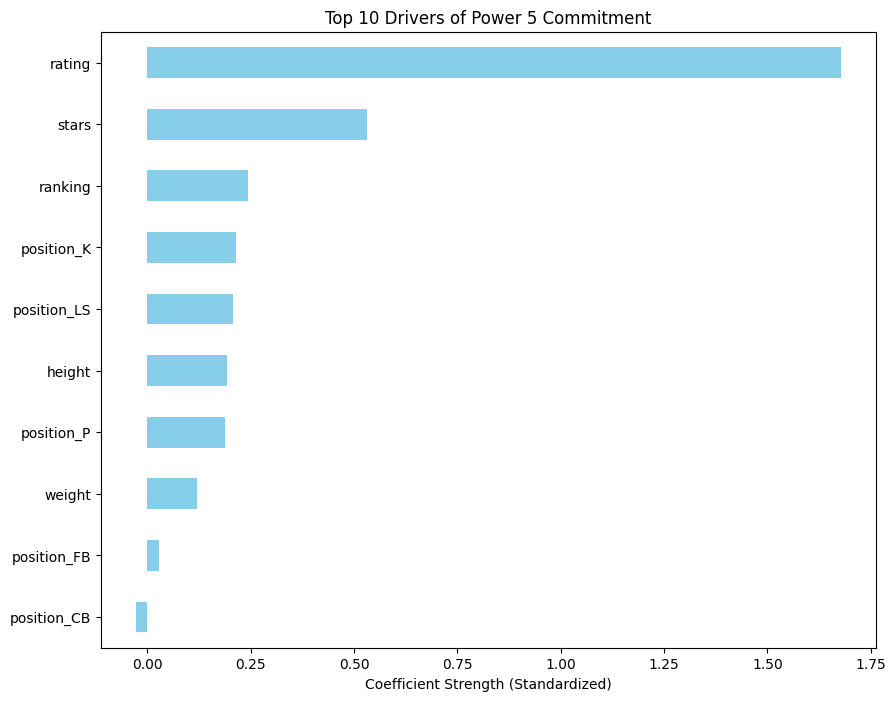

In [ ]:
import matplotlib.pyplot as plt

# Get the coefficients
importance = model_v2.coef_[0]
feature_names = X.columns

# Sort them
feat_importances = pd.Series(importance, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feat_importances.tail(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Drivers of Power 5 Commitment')
plt.xlabel('Coefficient Strength (Standardized)')
plt.show()

lets try decsion tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. Prepare data (No scaling needed!)
# Using the same X (with dummies) and y from before
X = pd.get_dummies(df_ml.drop('power_5', axis=1), drop_first=True)
y = df_ml['power_5']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize and Train
# max_depth=5 prevents the tree from memorizing the data
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

# 3. Evaluate
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print("--- Decision Tree Performance ---")
print(classification_report(y_test, y_pred_dt))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_dt):.4f}")

--- Decision Tree Performance ---
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      3874
           1       0.87      0.60      0.71      1314

    accuracy                           0.87      5188
   macro avg       0.87      0.78      0.81      5188
weighted avg       0.87      0.87      0.87      5188

ROC-AUC Score: 0.8727


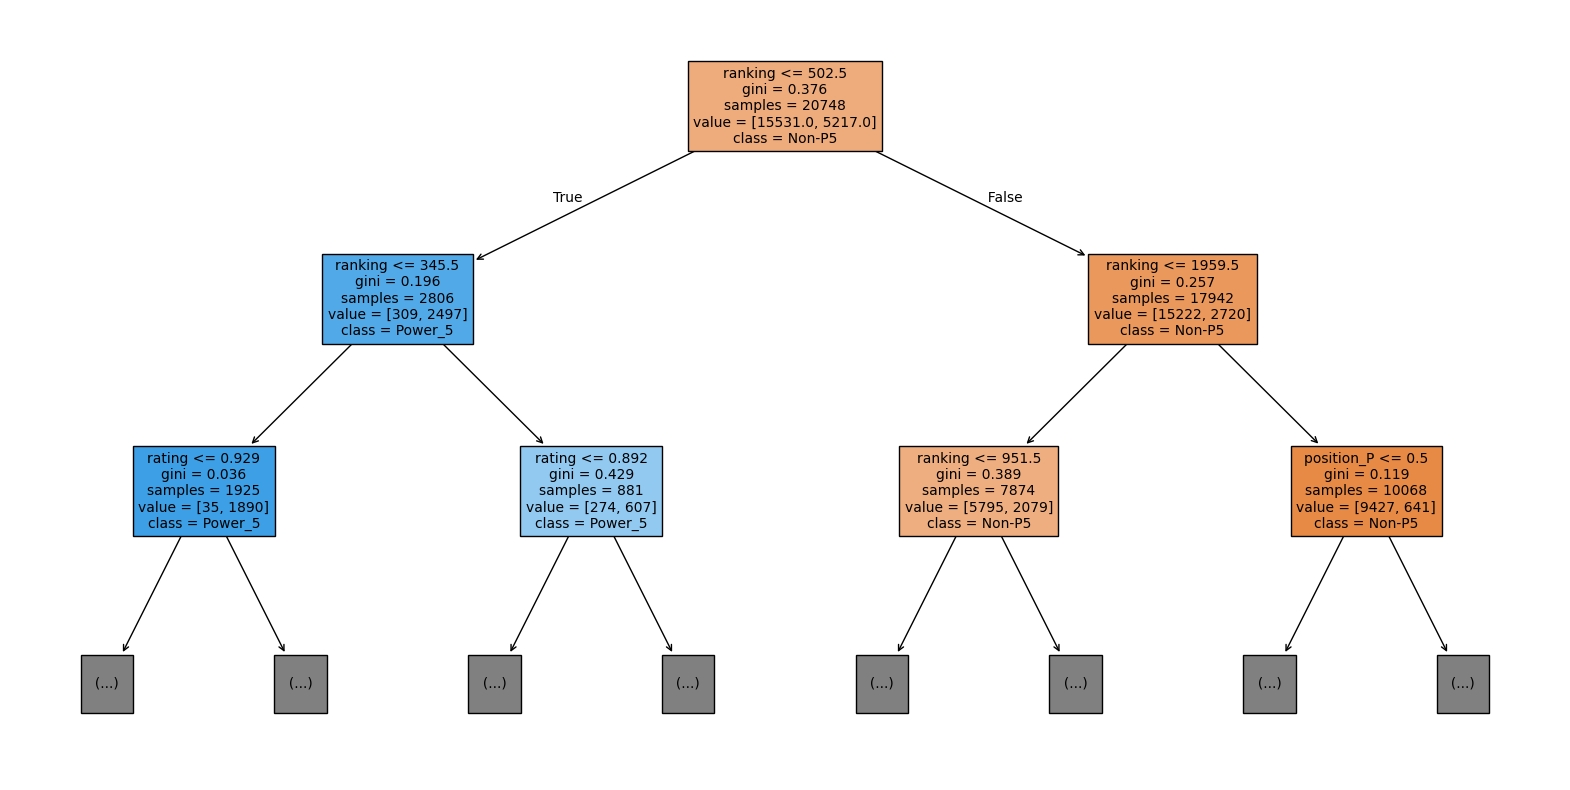

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(dt_model,
          feature_names=X.columns,
          class_names=['Non-P5', 'Power_5'],
          filled=True,
          fontsize=10,
          max_depth=2) # Showing only the top 2 levels for clarity
plt.show()

In [ ]:
# Check training performance
y_train_pred = dt_model.predict(X_train)
print("--- Training Performance ---")
print(classification_report(y_train, y_train_pred))

--- Training Performance ---
              precision    recall  f1-score   support

           0       0.89      0.98      0.93     15531
           1       0.92      0.62      0.74      5217

    accuracy                           0.89     20748
   macro avg       0.90      0.80      0.84     20748
weighted avg       0.89      0.89      0.88     20748



random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Check the new Test results
y_pred_rf = rf_model.predict(X_test)
print("--- Random Forest Performance ---")
print(classification_report(y_test, y_pred_rf))

--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.85      0.98      0.91      3874
           1       0.91      0.49      0.64      1314

    accuracy                           0.86      5188
   macro avg       0.88      0.74      0.77      5188
weighted avg       0.86      0.86      0.84      5188



In [ ]:
# 'balanced' tells the model to treat the smaller P5 group with more importance
rf_balanced = RandomForestClassifier(n_estimators=100,
                                     max_depth=10,
                                     class_weight='balanced',
                                     random_state=42)
rf_balanced.fit(X_train, y_train)

y_pred_bal = rf_balanced.predict(X_test)
print("--- Balanced Random Forest Performance ---")
print(classification_report(y_test, y_pred_bal))

--- Balanced Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.90      0.85      0.88      3874
           1       0.63      0.73      0.67      1314

    accuracy                           0.82      5188
   macro avg       0.76      0.79      0.78      5188
weighted avg       0.83      0.82      0.83      5188



In [ ]:
from xgboost import XGBClassifier

# 1. Initialize XGBoost
# scale_pos_weight helps with the class imbalance (approx 3:1 ratio)
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=3, # Adjusts for having fewer Power 5 kids
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# 2. Fit the model
xgb_model.fit(X_train, y_train)

# 3. Evaluate
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("--- XGBoost Performance ---")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:49:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Performance ---
              precision    recall  f1-score   support

           0       0.92      0.86      0.89      3874
           1       0.65      0.78      0.71      1314

    accuracy                           0.84      5188
   macro avg       0.78      0.82      0.80      5188
weighted avg       0.85      0.84      0.84      5188

ROC-AUC Score: 0.8949


decision tree(max_depth=5) - not good  
decision tree(max_depth=10) - pretty good  
reandom forest - not good  
xgb - pretty good  
  
xgb vs decision tree:  
use the decision tree(good precision) if you want a safe bet list with no junk data - this will only give us good players but might miss some talent

use xgboost(good recall) if you are a scout who doesn't want to miss a single sleeper and is willing to manually vet the extra results - this will give us a lot of potentially good players but some might not be good

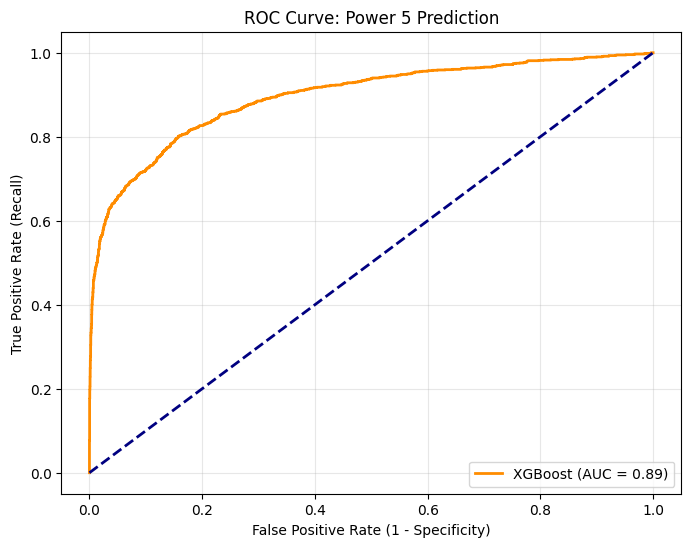

163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


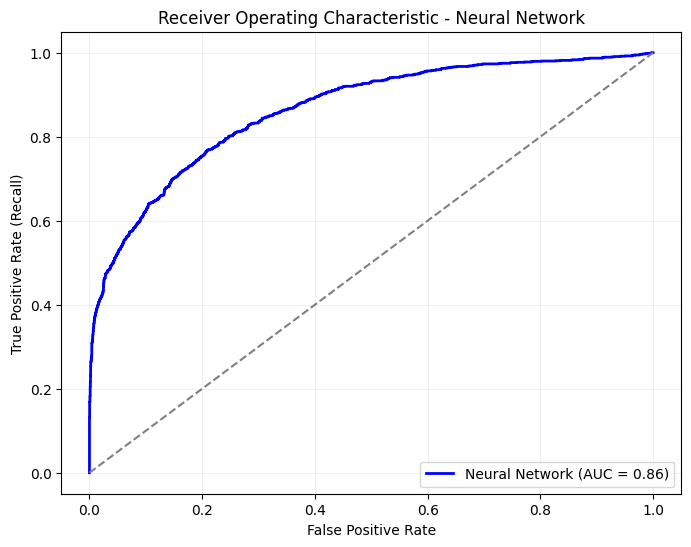

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Get the probabilities for the positive class (Power 5)
# [:, 1] grabs the probability of being '1'
y_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]

# 2. Calculate the ROC curve data
fpr, tpr, thresholds = roc_curve(y_test, y_probs_xgb)
auc_score = roc_auc_score(y_test, y_probs_xgb)

# 3. Plot the results
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # The "Random Guess" line
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve: Power 5 Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Get probabilities from the NN
# Keras model.predict returns a 2D array, so we flatten it to 1D
y_probs_nn = model_deep.predict(X_test_scaled).ravel()

# 2. Calculate ROC metrics
fpr_nn, tpr_nn, thresholds_nn = roc_curve(y_test, y_probs_nn)
auc_nn = roc_auc_score(y_test, y_probs_nn)

# 3. Plot the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_nn, tpr_nn, color='blue', lw=2, label=f'Neural Network (AUC = {auc_nn:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # Random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic - Neural Network')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()